In [15]:
import sympy as sp
import numpy as np
from scipy.integrate import simpson
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

**Упражнение 1**

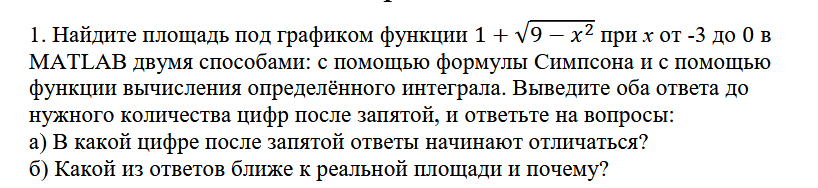

In [7]:
x = sp.Symbol('x')
f = 1 + sp.sqrt(9 - x**2)
a, b = -3, 0

exact_area_expr = sp.integrate(f, (x, a, b))
exact_area_numeric = float(exact_area_expr.evalf(20))
print(f"Точное значение площади: {exact_area_numeric:.20f} = {exact_area_expr}")
x1 = np.linspace(-3, 0, 1000)
print(simpson(1 + np.sqrt(9 - x1**2), x1))

Точное значение площади: 10.06858347057703539917 = 3 + 9*pi/4
10.068550743902323


**Упражнение 2**

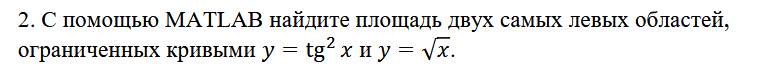

In [13]:
def find_roots():
    func = lambda x: np.tan(x)**2 - np.sqrt(x)
    x1 = 0.0
    x2 = fsolve(func, 0.8)[0]
    x3 = fsolve(func, 2.5)[0] 
    x4 = fsolve(func, 4.0)[0]
    return [x1, x2, x3, x4]

roots = find_roots()
x = sp.Symbol('x')
f = sp.sqrt(x) - sp.tan(x)**2

area1 = sp.integrate(f, (x, roots[0], roots[1]))

area2 = sp.integrate(f, (x, roots[2], roots[3]))

print(f"Площадь первой области: {area1:.6f}")
print(f"Площадь второй области: {area2:.6f}")

Площадь первой области: 0.251417
Площадь второй области: 2.472513


**Упражнение 3**

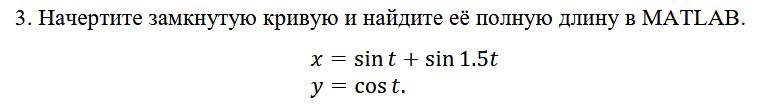

Подынтегральное выражение: sqrt((cos(t) + 1.5*cos(1.5*t))**2 + sin(t)**2)
Полная длина кривой (0 до 4pi): 16.7102393034068


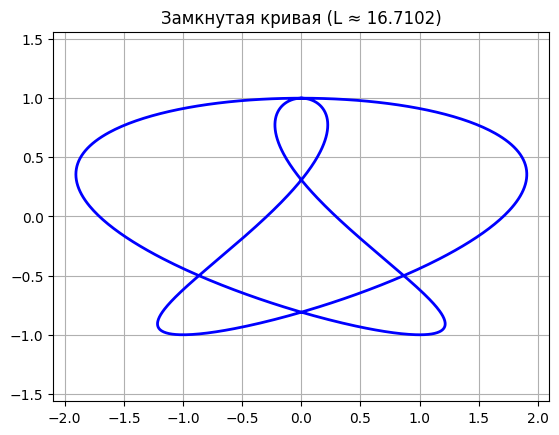

In [17]:
t = sp.Symbol('t')
x = sp.sin(t) + sp.sin(1.5 * t)
y = sp.cos(t)

dx_dt = sp.diff(x, t)
dy_dt = sp.diff(y, t)

integrand = sp.sqrt(dx_dt**2 + dy_dt**2)
length_expr = sp.Integral(integrand, (t, 0, 4 * sp.pi))
total_length = length_expr.evalf()

print(f"Подынтегральное выражение: {integrand}")
print(f"Полная длина кривой (0 до 4pi): {total_length}")

t_vals = np.linspace(0, 4 * np.pi, 1000)
x_vals = np.sin(t_vals) + np.sin(1.5 * t_vals)
y_vals = np.cos(t_vals)

plt.plot(x_vals, y_vals, 'b-', lw=2)
plt.title(f"Замкнутая кривая (L ≈ {total_length:.4f})")
plt.grid(True)
plt.axis('equal')
plt.show()

**Упражнение 4**

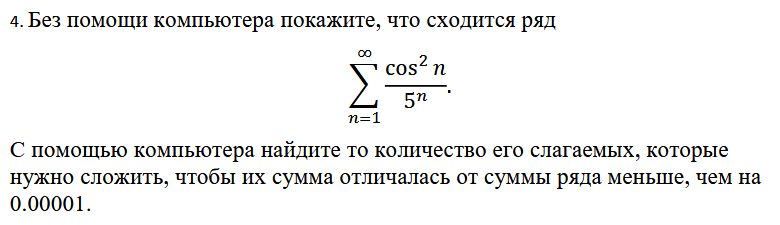

$\sum_{n=1}^{\infty}{\frac{\cos^2{n}}{5^n}}$

$\frac{\cos^2{n}}{5^n} < \frac{1}{5^n}$

$\sum_{n=1}^{\infty}{\frac{1}{5^n}} = \frac{\frac{1}{5}}{1-\frac{1}{5}} = 0.25$ - сходится

По признаку сравнения $\sum_{n=1}^{\infty}{\frac{\cos^2{n}}{5^n}}$ сходится

In [18]:
n = sp.Symbol('n')
a_n = sp.cos(n)**2 / 5**n
total_sum = sp.summation(a_n, (n, 1, sp.oo)).evalf()
current_sum = 0
epsilon = 0.00001
N = 0

while True:
    N += 1
    current_sum += float(a_n.subs(n, N).evalf())
    if abs(total_sum - current_sum) < epsilon:
        break

print(f"Точная сумма ряда: {total_sum}")
print(f"Необходимое количество слагаемых N: {N}")
print(f"Сумма первых {N} слагаемых: {current_sum}")

Точная сумма ряда: 0.0739293069984864
Необходимое количество слагаемых N: 6
Сумма первых 6 слагаемых: 0.07392147692959532


**Упражнение 5**

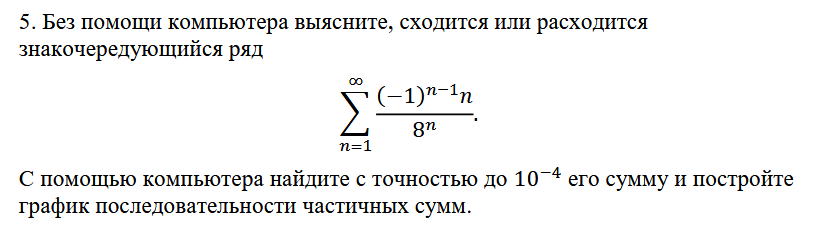

Признак Лейбница:

1: $\lim_{n->\infty}{\frac{n}{8^n}} = 0$

2: $\frac{a_{n+1}}{a_n} = \frac{n+1}{8n} < 1$ при $n \ge 1$

По признаку Лейбница ряд сходится

Точная сумма ряда: 8/81 (≈ 0.098765)
Сумма с точностью 10^-4: 0.098763
Количество итераций: 6


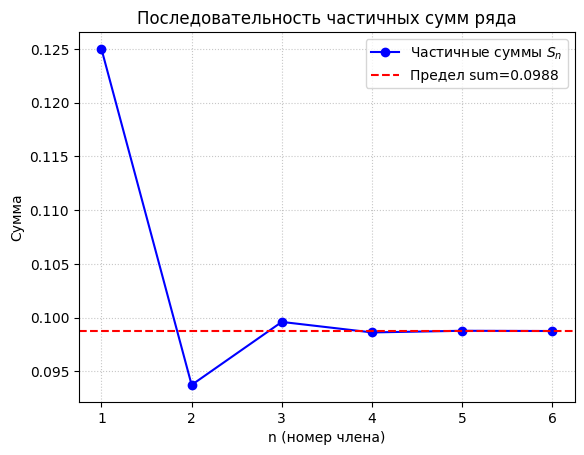

In [19]:
n = sp.symbols('n')
expr = ((-1)**(n-1) * n) / (8**n)
exact_sum = sp.summation(expr, (n, 1, sp.oo))
print(f"Точная сумма ряда: {exact_sum} (≈ {float(exact_sum):.6f})")
epsilon = 1e-4
current_sum = 0
n_val = 1
partial_sums = []

while True:
    term = ((-1)**(n_val-1) * n_val) / (8**n_val)
    current_sum += term
    partial_sums.append(current_sum)
    if abs(term) < epsilon:
        break
    n_val += 1

print(f"Сумма с точностью 10^-4: {current_sum:.6f}")
print(f"Количество итераций: {n_val}")

plt.plot(range(1, n_val + 1), partial_sums, 'o-', color='blue', label='Частичные суммы $S_n$')
plt.axhline(y=float(exact_sum), color='red', linestyle='--', label=f'Предел sum={float(exact_sum):.4f}')

plt.title('Последовательность частичных сумм ряда')
plt.xlabel('n (номер члена)')
plt.ylabel('Сумма')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

**Упражнение 6**

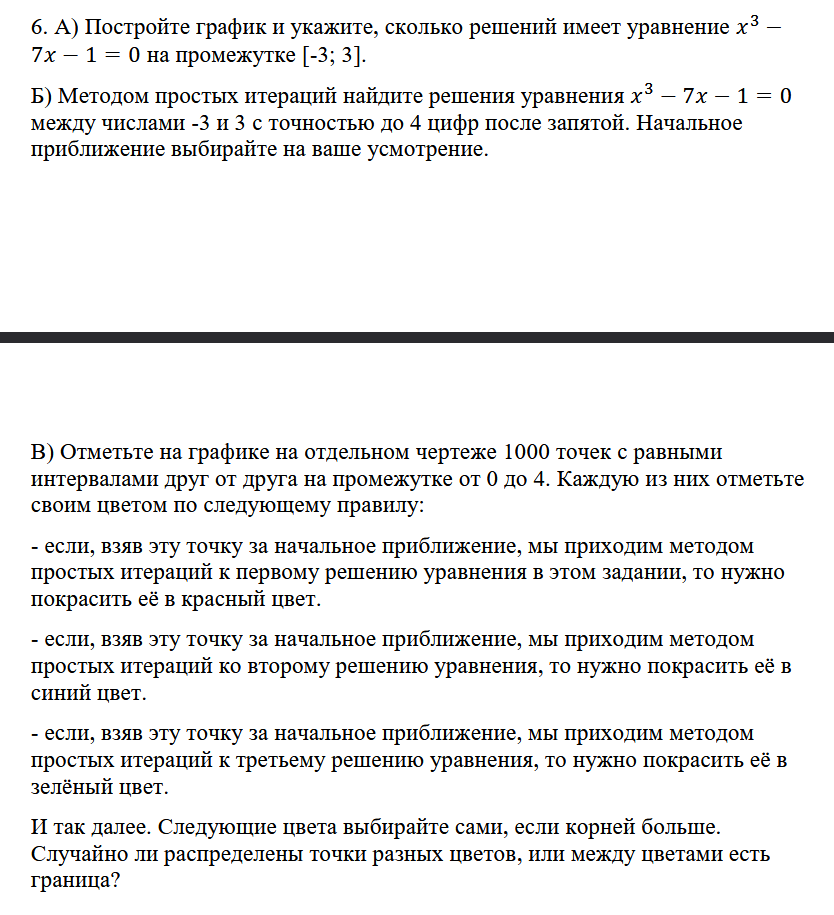

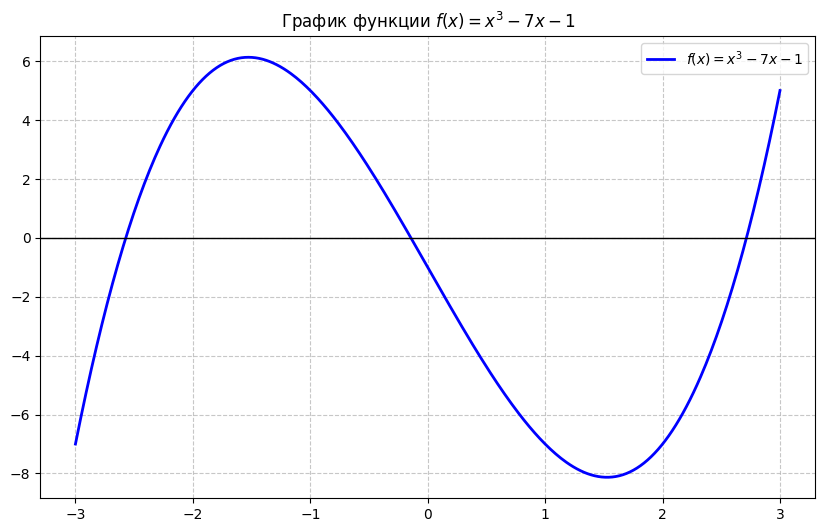

In [22]:
x = np.linspace(-3, 3, 400)
y = x**3 - 7*x - 1
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='$f(x) = x^3 - 7x - 1$', color='blue', lw=2)
plt.axhline(0, color='black', lw=1) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('График функции $f(x) = x^3 - 7x - 1$')
plt.legend()
plt.show()

3 решения

$x \approx -2.5$ : $x = \sqrt[3]{7x+1}$

$x \approx -0.1$ : $x = -\sqrt{7+\frac{1}{x}}$

$x \approx 2.7$ : $x = \sqrt[3]{7x+1}$

In [23]:
def solve_iterations():
    x = 3.0
    for _ in range(100):
        x_new = (7*x + 1)**(1/3)
        if abs(x_new - x) < 1e-5: break
        x = x_new
    x1 = x
    
    x = 0.0
    for _ in range(100):
        x_new = (x**3 - 1) / 7
        if abs(x_new - x) < 1e-5: break
        x = x_new
    x2 = x

    x = -2.5
    for _ in range(100):
        x_new = -np.sqrt(7 + 1/x)
        if abs(x_new - x) < 1e-5: break
        x = x_new
    x3 = x

    return x1, x2, x3

roots = solve_iterations()
for i, root in enumerate(roots, 1):
    print(f"Корень x{i}: {root:.4f}")

Корень x1: 2.7145
Корень x2: -0.1433
Корень x3: -2.5712


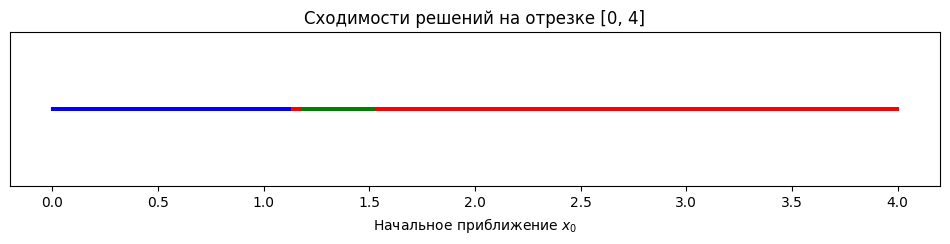

In [34]:
def f(x): return x**3 - 7*x - 1
def df(x): return 3*x**2 - 7

roots = [2.7145, -0.1433, -2.5712]
colors = ['red', 'blue', 'green']

x_points = np.linspace(0, 4, 1000)
point_colors = []

for x0 in x_points:
    x = x0
    for _ in range(20):
        if abs(df(x)) < 1e-6: break 
        x = x - f(x)/df(x)

    found_root = False
    for i, root in enumerate(roots):
        if abs(x - root) < 1e-3:
            point_colors.append(colors[i])
            found_root = True
            break
    
    if not found_root:
        point_colors.append('gray') 


plt.figure(figsize=(12, 2))
plt.scatter(x_points, np.zeros_like(x_points), c=point_colors, s=10, marker='|')
plt.title('Сходимости решений на отрезке [0, 4]')
plt.xlabel('Начальное приближение $x_0$')
plt.yticks([]) 
plt.grid(False)
plt.show()

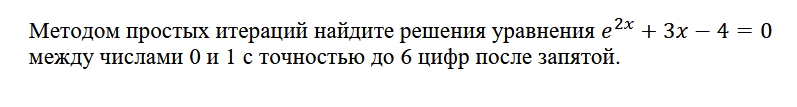

$ e^{2x} = 4-3x$

$2x = \ln{(4-3x)}$

$x = \frac{\ln{(4-3x)}}{2}$

In [39]:
def phi(x):
    return 0.5 * np.log(4 - 3*x)

def solve_iterations(x0, eps):
    x_prev = x0
    iteration = 0
    
    while True:
        iteration += 1
        x_curr = phi(x_prev)
        diff = abs(x_curr - x_prev)
        
        if diff < eps:
            break
        x_prev = x_curr
        
    return x_curr

root = solve_iterations(x0=0.5, eps=1e-7) 
print(f"\nНайденный корень: {root:.6f}")


Найденный корень: 0.473688
